# Alluvial Diagrams

DS 2023 | Communicating with Data

<!-- <img src="https://virginia.box.com/shared/static/5ykx63njw8amir6c1u62r19gqwx8xm57.png" width="650"/> -->

<img src="https://virginia.box.com/shared/static/iixwxz7rhjq5n8d8bhvvwn0r1ultbzi2.png"/>

## Overview

An **alluvial diagram** shows how the observations in a dataset split and combine across a series of categorical variables.

Each **categorical variable** gets its own vertical **axis**.

Each **category value** on an axis is shown as a block, called a **stratum**, with height proportional to its count.

Bands called **flows** or **ribbons** connect the strata on neighboring axes.

The **width of a flow** stands for the number of observations that share both categories.

**Every observation travels through every axis**, so the total height of each axis is the same.

> [!NOTE]
>
> The name comes from [Rosvall and Bergstrom (2010)](https://arxiv.org/abs/0812.1242), who used these diagrams to show how scientific fields merged and split over time, like sediment in a river delta.
>
> The word **alluvial** comes from the **alluvium**, a Medieval Latin noun meaning "matter deposited by flowing water," itself deriving from Latin **alluere**, "to wash against."
>
> The general idea itself goes back to Matthew Sankey, who drew energy flowing through a steam engine in 1898, and Bendix, Kosara and Hauser introduced **parallel sets** for categorical data in 2005.

## Use Cases

**Cross-classification:** how one population splits along several categories at once, e.g. who survived the Titanic, by class and sex.

**Contingency tables:** making a multi-way table of counts visible, e.g. admissions to a university by department and gender.

**Repeated measures:** the same subjects observed at several times, e.g. students changing majors from semester to semester.

## Creating an alluvial diagram from scratch

Think of an alluvial diagram as something like **a connected set of stacked bar charts**.

Let's create the bars and show how they are connected into an alluvial.

We will use the `titanic` dataset and `class`, `sex`, and `alive` as our group variables.

To prepare the data, we will first convert the group variables to **categorical** data types.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset('titanic')
titanic_group_cols = ['class', 'sex', 'alive']
titanic[titanic_group_cols] = titanic[titanic_group_cols].astype('category')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Since we want to compare three columns &mdash; `class`, `sex`, and `alive` &mdash;  we use `value_counts` to get the number of observations for each combination.

This tells us how much data "flows" from one variable to another.

For example, we can see that $336$ observations (people) flow from being `class = 'Third'` and `sex = 'male'` to not surviving (`alive = 'no'`).

```{note}
Here we get a normalized value count, so that the flows represent relative frequencies and not raw values. 

We also convert the values in $[0,1]$ so they are easier to plot.
```

In [186]:
flows = titanic.value_counts(titanic_group_cols, normalize=True).to_frame('n').reset_index()
flows['n'] = (flows['n'] * 1000).astype(int)
# flows = titanic.value_counts(group_cols).to_frame('n').reset_index()
flows

,class,sex,alive,n
0,Third,male,no,336
1,First,female,yes,102
2,Second,male,no,102
3,First,male,no,86
4,Third,female,no,80
5,Third,female,yes,80
6,Second,female,yes,78
7,Third,male,yes,52
8,First,male,yes,50
9,Second,male,yes,19


**Pick a key column**

Before we construct the vertical axes and their strata, we need to pick a grouping variable.

This variable that will be used to color the ribbons.

In [187]:
# key_col = 'alive'
key_col = 'class'
# key_col = 'sex'

**Create the vertical axes and strata**

Next, we compute the strata for each vertical axis.

These can be acquired by **sorting the columns** by the axis variable, followed by the other variables, and then computing the cumulative sums.

We also add a little gap between each category for each variable.

In [188]:
gap = 10
for i, col in enumerate(titanic_group_cols):
    sort_cols = titanic_group_cols.copy()
    sort_cols.insert(0, sort_cols.pop(i)) # Pull out the current col and put it first
    print(i, col, sort_cols, sep="\t")
    flows[f'{col}_y'] = flows.sort_values(sort_cols).n.cumsum() + flows[col].cat.codes * gap
flows

0	class	['class', 'sex', 'alive']
1	sex	['sex', 'class', 'alive']
2	alive	['alive', 'class', 'sex']


,class,sex,alive,n,class_y,sex_y,alive_y
0,Third,male,no,336,962,952,613
1,First,female,yes,102,105,105,725
2,Second,male,no,102,437,597,197
3,First,male,no,86,191,445,89
4,Third,female,no,80,546,269,277
5,Third,female,yes,80,626,349,952
6,Second,female,yes,78,335,189,853
7,Third,male,yes,52,1014,1004,1004
8,First,male,yes,50,241,495,775
9,Second,male,yes,19,456,616,872


You can see how the cumulative sums and gaps will be used to construct the vertical axes and strata.

In the stacked bar chart below, each column shows the same data, just grouped and sorted differently.

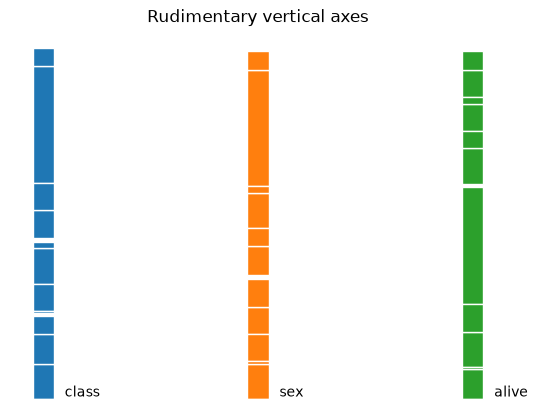

In [189]:
for i, col in enumerate(titanic_group_cols):
    plt.bar(i, flows.n, bottom=flows[f'{col}_y'] - flows.n, edgecolor='white', width=.1)
    plt.text(i + .1, 10, col)
sns.despine(left=True, bottom=True)
plt.xticks([])
plt.yticks([])
plt.title("Rudimentary vertical axes")
plt.show()

**Plot the diagram**

Now, we plot the vertical axes, strata, and ribbons.

First, we'll pick a suitable colormap to color the strata and ribbons.

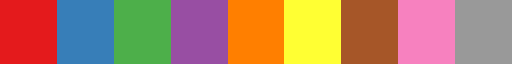

In [190]:
cmap = plt.colormaps.get_cmap('Set1')
cmap

Then we get the category object for our `key_col` so we can grab the category code for the value of the `key_col` at runtime.

In [191]:
key_cats = flows[key_col].cat.categories
key_cats

Index(['First', 'Second', 'Third'], dtype='str')

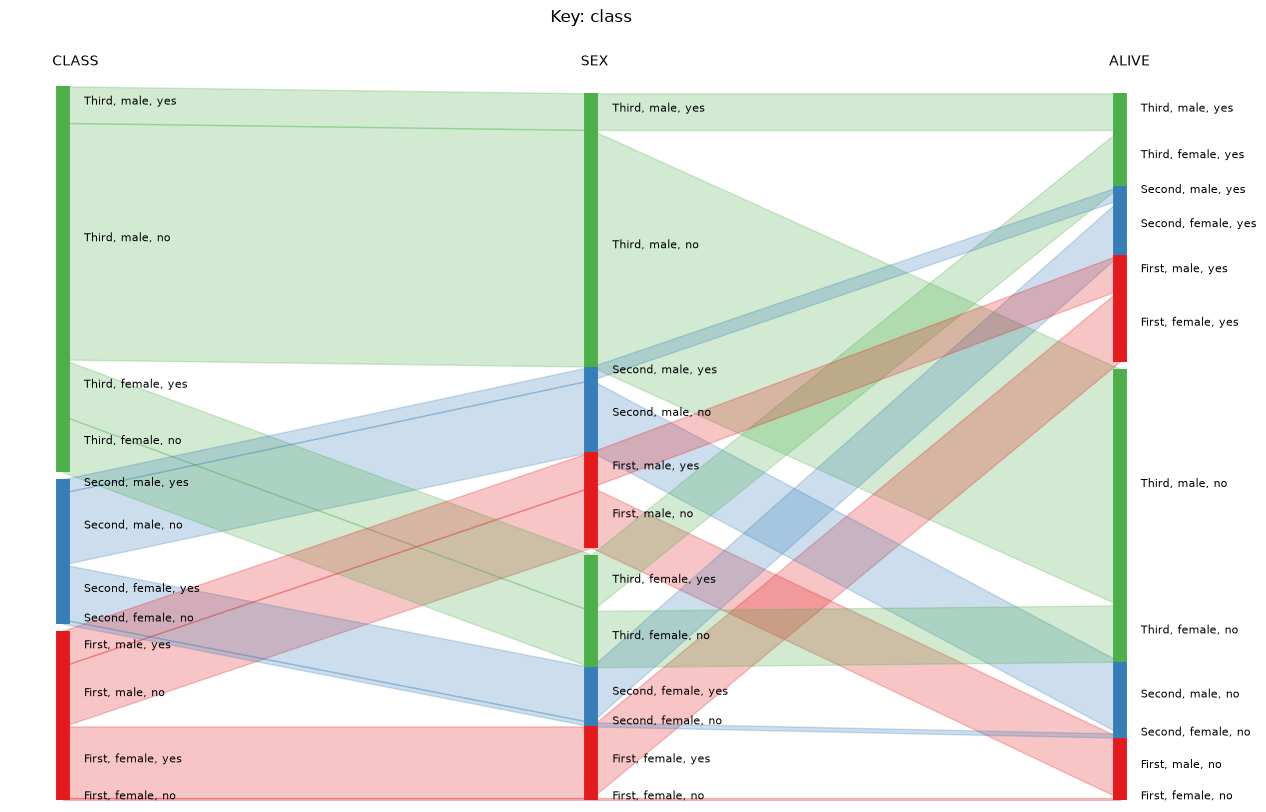

In [192]:
plt.figure(figsize=(15,10))

for idx, row in flows.iterrows():

    # Get the height of the stratum
    n = row['n']

    # Get the color for this row
    key_col_val = row[key_col]
    key_col_code = key_cats.get_loc(key_col_val)
    color = cmap(key_col_code)

    # Plot the markers
    for i, col in enumerate(titanic_group_cols):

        # Get the x axis offset of the grouping col, starting with 1
        x = i + 1

        # Get the y value, i.e. the cumulative value
        y = row[f'{col}_y']

        # Plot the bars
        plt.plot([x, x], [y - n, y], lw=10, color=color, solid_capstyle='butt')

        # Add a label using plt.text(x, y, text)
        plt.text(x + .04, y - n/2, ", ".join(row[titanic_group_cols].values), fontsize=8)

    # Plot the ribbons using fill_between
    x_vals = [i+1 for i in range(len(titanic_group_cols))]                        # Again, get the x axis offsets 
    y_vals = row[[f"{col}_y" for col in titanic_group_cols]].values.astype(float) # Get the pair of y values
    plt.fill_between(x_vals, y_vals, y_vals - n, alpha=.25, color=color)

# Add labels to each vertical axis
N = flows.n.sum()
for i, col in enumerate(titanic_group_cols):
    plt.text(i+1 - .02, N + N * .05, col.upper())

# Title
plt.title(f"Key: {key_col}")

# Clean up
plt.ylim(0, N + N * .1)
sns.despine(left=True, bottom=True)
plt.xticks([])
plt.yticks([])

plt.show()

Notice how much of the Third-class stratum flows into `no`.

## Using Plotly

Now let's use Plotly to create an alluvial diagram from the same data.

It does a much better job of it, but the logic behind the diagram is the same.

In [193]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

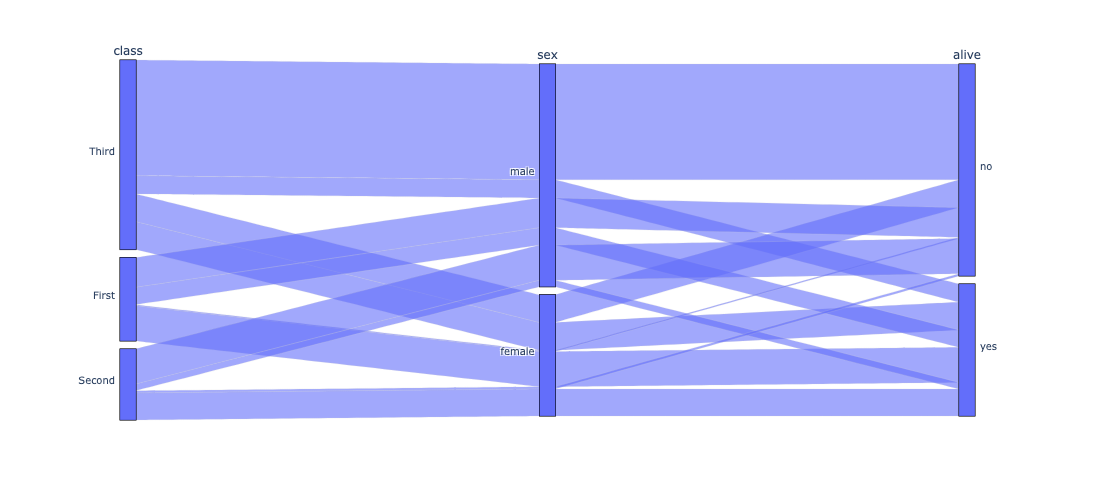

In [194]:
px.parallel_categories(
    titanic[titanic_group_cols],  
    height=500, width=800
)

We can see the three axes and the flows between them.

Hover over a flow to see its count.

You can also drag a stratum up or down to reorder it.

**Coloring by a variable**

Let's color the flows by whether the passenger survived.

Let's also put `alive` first, so the color starts at the left and we read the diagram backward from the outcome.

Finally, `line_shape='hspline'` curves the flows, which makes them easier to follow.

In [195]:
plotly_cmap = px.colors.qualitative.Set1

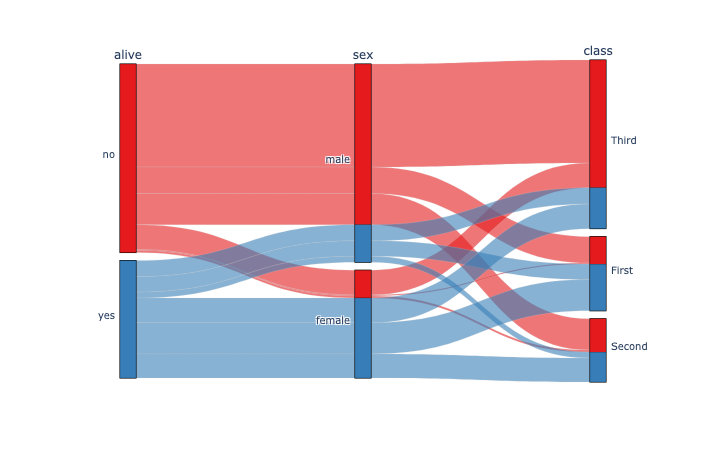

In [196]:
fig = px.parallel_categories(
    titanic,
    dimensions=['alive','sex','class'], 
    color=titanic['alive'].cat.codes,
    # color_continuous_scale=plotly_cmap,
    color_continuous_scale=plotly_cmap[:len(titanic['alive'].unique())],
    width=800, height=450,
)
fig.update_traces(line_shape='hspline')
fig.update_layout(coloraxis_showscale=False)
fig.show()

**The diagram tells a story.**

Most first-class passengers survived, and most third-class passengers did not.

Notice the `sex` axis: about two thirds of the survivors were women, and most of the men did not survive.

What else can you see?

## Tidy data

### Penguins

Let's look at how the grouping variables of the Penguins dataset are related.

```{note}
In this table, and going forward, we convert all grouping variables to categories.

This is because Plotly wants to use numbers when assigning colors.
```

In [197]:
penguins = sns.load_dataset('penguins').dropna()
penguins_group_cols = ['species', 'sex', 'island']
penguins[penguins_group_cols] = penguins[penguins_group_cols].astype('category')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


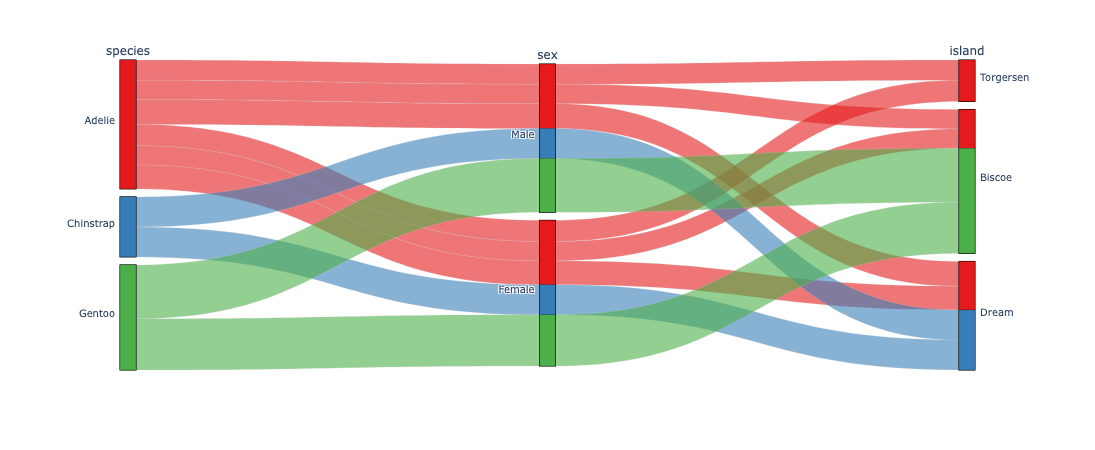

In [198]:
fig = px.parallel_categories(
    penguins,
    dimensions=['species', 'sex', 'island'],
    color=penguins.species.cat.codes,
    color_continuous_scale=plotly_cmap[:len(penguins['species'].unique())],
    width=800, height=450,
)
fig.update_traces(line_shape='hspline')
fig.update_layout(coloraxis_showscale=False)
fig.show()

Notice the flows that are missing.

Gentoo live only on Biscoe, and Chinstrap only on Dream.

Adelie are the only species found on all three islands.

**An alluvial diagram shows the absence of a combination as clearly as its presence.**

Notice also the sex doesn't matter much in the diagram since the data are balanced over that variable.

> [!TIP]
>
> Notice that when setting `color_continuous_scale` (the same as `cmap` in Matplotlib), we didn't just pass the colormap.
>
> We passed a slice of it equal in length to the number of categories to color in.
>
> ```python
> color_continuous_scale=plotly_cmap[:len(penguins['species'].unique())]
> ```
> This is because when Plotly maps numbers to colormaps, it picks colors from the colormap as a whole, matching the highest category number to the highest color value.
>
> But we want to get colors in the order of their appearance.

### Cars

Numeric measurement variables can be axes too, as long as they have only a few distinct values.

Here `cylinders` has five values, and we bin `model_year` into three periods.

In [202]:
mpg = sns.load_dataset('mpg')
mpg['period'] = pd.cut(
    mpg['model_year'], 
    bins=[69, 73, 77, 82],
    labels=['1970–73', '1974–77', '1978–82']
)
mpg_group_cols = ['origin', 'cylinders', 'period']
mpg[mpg_group_cols] = mpg[mgg_group_cols].astype('category')
mpg[mpg_group_cols]

,origin,cylinders,period
0,usa,8,1970–73
1,usa,8,1970–73
2,usa,8,1970–73
3,usa,8,1970–73
4,usa,8,1970–73
...,...,...,...
393,usa,4,1978–82
394,europe,4,1978–82
395,usa,4,1978–82
396,usa,4,1978–82


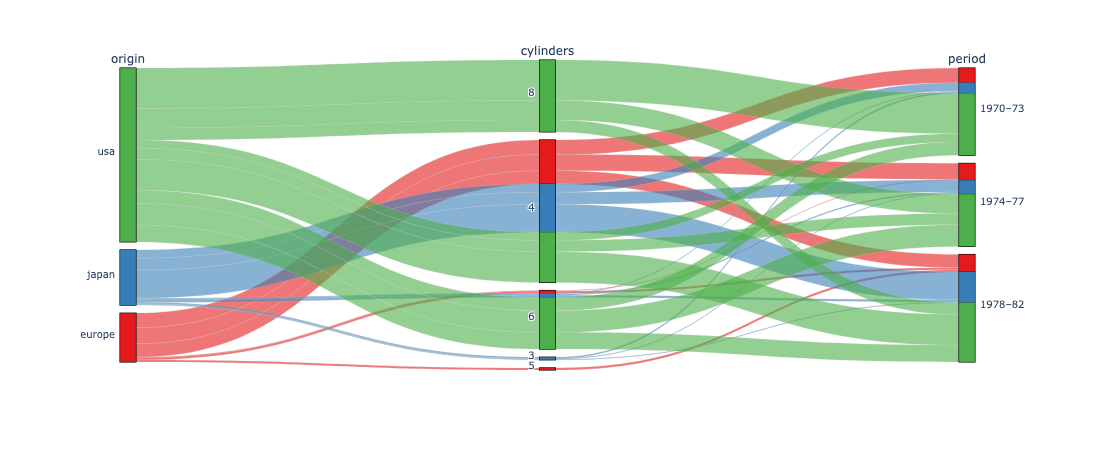

In [203]:
fig = px.parallel_categories(
    mpg,
    dimensions=['origin', 'cylinders', 'period'],
    color=mpg['origin'].cat.codes,
    color_continuous_scale=plotly_cmap[:len(mpg['origin'].unique())],
    width=800, height=450,
)
fig.update_traces(line_shape='hspline')
fig.update_layout(coloraxis_showscale=False)
fig.show()

Nearly every eight-cylinder car is American.

Follow the `8` stratum into the last period and notice how much thinner it gets after the oil crises.

## Aggregated data

### College admissions

Many classic datasets come already counted: one row per combination, with a frequency column.

To use them with `px.parallel_categories`, we have to **expand** each row into one row per person with `index.repeat`.

This turns a table of counts back into a table of observations.

In [204]:
ucb_data_url = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/UCBAdmissions.csv"
ucb = pd.read_csv(ucb_data_url).drop('rownames', axis=1)
ucb.info()
ucb.head()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Admit   24 non-null     str  
 1   Gender  24 non-null     str  
 2   Dept    24 non-null     str  
 3   Freq    24 non-null     int64
dtypes: int64(1), str(3)
memory usage: 1.2 KB


,Admit,Gender,Dept,Freq
0,Admitted,Male,A,512
1,Rejected,Male,A,313
2,Admitted,Female,A,89
3,Rejected,Female,A,19
4,Admitted,Male,B,353


In [205]:
ucb_group_cols = ['Admit','Gender', 'Dept']

In [206]:
ucb[ucb_group_cols] = ucb[ucb_group_cols].astype('category')

In [207]:
people = ucb.loc[ucb.index.repeat(ucb['Freq'])].reset_index(drop=True).drop('Freq', axis=1)
people

,Admit,Gender,Dept
0,Admitted,Male,A
1,Admitted,Male,A
2,Admitted,Male,A
3,Admitted,Male,A
4,Admitted,Male,A
...,...,...,...
4521,Rejected,Female,F
4522,Rejected,Female,F
4523,Rejected,Female,F
4524,Rejected,Female,F


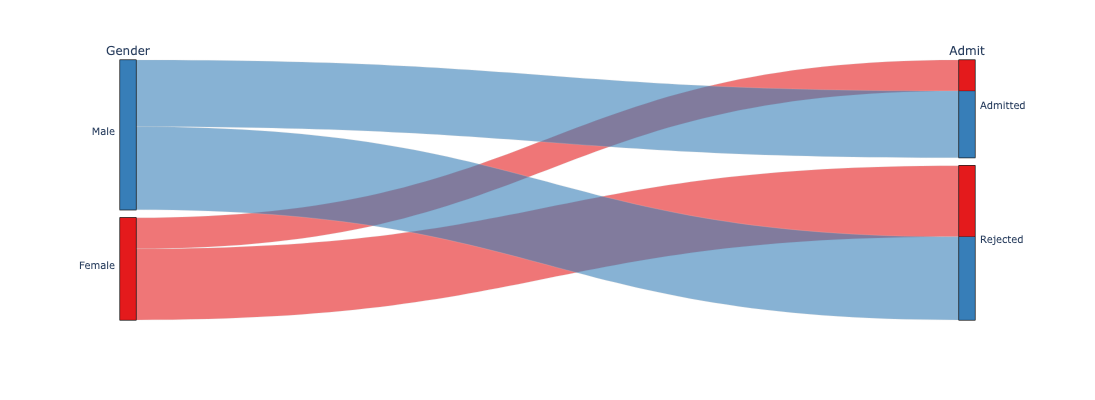

In [208]:
fig = px.parallel_categories(
    people, 
    dimensions=['Gender', 'Admit'], 
    color=people.Gender.cat.codes,
    color_continuous_scale=plotly_cmap[:len(people.Gender.unique())],
    width=600, height=400,
)
fig.update_traces(line_shape='hspline')
fig.update_layout(coloraxis_showscale=False)
fig.show()

Women seem to be admitted at a lower rate than men.

Now let's add the department in the middle.

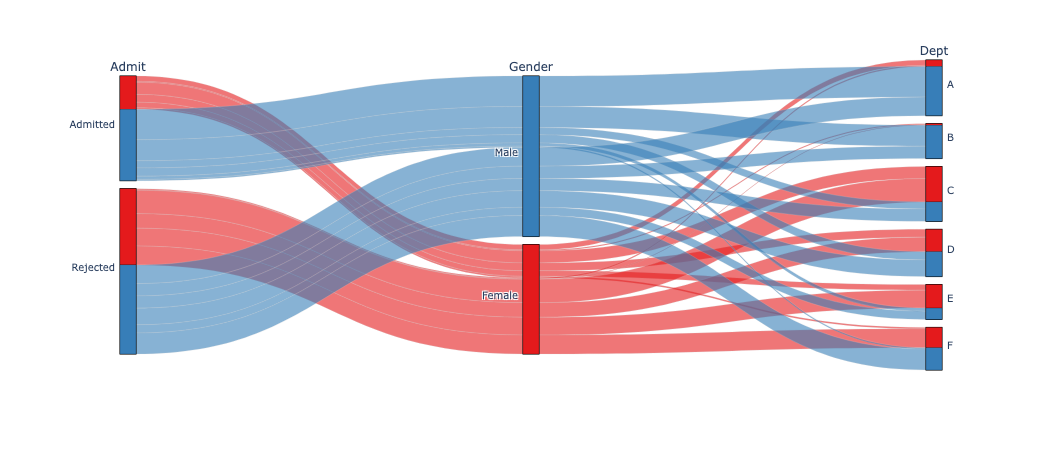

In [209]:
fig = px.parallel_categories(
    people, 
    dimensions=ucb_group_cols, 
    color=people.Gender.cat.codes,
    color_continuous_scale=plotly_cmap[:len(people.Gender.unique())],
    width=800, height=450,
)
fig.update_traces(line_shape='hspline')
fig.update_layout(coloraxis_showscale=False)
fig.show()

Notice where the orange goes.

Most women applied to departments C through F, which reject most applicants of either gender.

Most men applied to A and B, which admit most applicants.

Let's check the rates directly.

In [210]:
rates = (ucb
    .pivot_table(index='Dept', columns=['Gender', 'Admit'], values='Freq', aggfunc='sum')
    .pipe(lambda t: pd.DataFrame({
        g: t[(g, 'Admitted')] / (t[(g, 'Admitted')] + t[(g, 'Rejected')]) for g in ['Male', 'Female']
    }))
    .round(2))
rates

,Male,Female
Dept,,
A,0.62,0.82
B,0.63,0.68
C,0.37,0.34
D,0.33,0.35
E,0.28,0.24
F,0.06,0.07


Within four of the six departments, women were admitted at a higher rate than men.

This reversal is called **Simpson's paradox**.

The two-axis diagram suggests one story, and the three-axis diagram tells the opposite one.

Which axes we include is a claim about what matters.

### Hair and eye color

Here we color by hair color, using colors that mean something.

In [211]:
hec_data_url = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/HairEyeColor.csv"
hec = pd.read_csv(hec_data_url).drop('rownames', axis=1)
hec.info()
hec.head()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Hair    32 non-null     str  
 1   Eye     32 non-null     str  
 2   Sex     32 non-null     str  
 3   Freq    32 non-null     int64
dtypes: int64(1), str(3)
memory usage: 1.6 KB


,Hair,Eye,Sex,Freq
0,Black,Brown,Male,32
1,Brown,Brown,Male,53
2,Red,Brown,Male,10
3,Blond,Brown,Male,3
4,Black,Blue,Male,11


In [212]:
hec_group_cols = "Hair Eye Sex".split()
hec[hec_group_cols] = hec[hec_group_cols].astype('category')
hec_people = hec.loc[hec.index.repeat(hec['Freq'])].reset_index(drop=True).drop('Freq', axis=1)
hec_people.sample(5)

,Hair,Eye,Sex
354,Brown,Brown,Female
290,Black,Brown,Female
60,Brown,Brown,Male
207,Black,Hazel,Male
545,Brown,Hazel,Female


**Define colors to display hair color.**

In [213]:
hair_colors = {c:c.lower() for c in hec.Hair.cat.categories}
hair_colors

{'Black': 'black', 'Blond': 'blond', 'Brown': 'brown', 'Red': 'red'}

In [214]:
hair_colors['Blond'] = 'gold' 
hair_colors['Brown'] = 'chocolate' #'brown' #'#8B4513'
hair_colors['Red'] = 'orange'

In [215]:
list(hair_colors.values())

['black', 'gold', 'chocolate', 'orange']

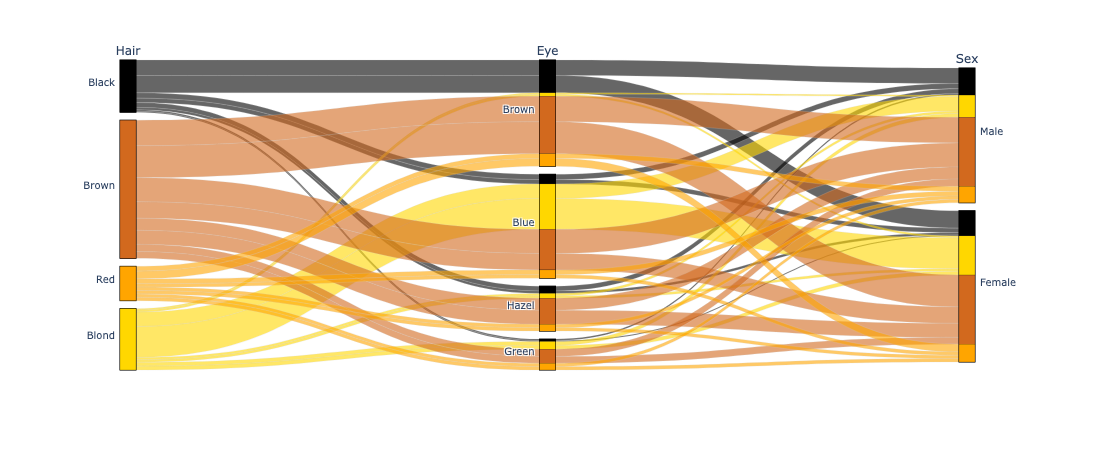

In [216]:
fig = px.parallel_categories(
    hec_people, 
    dimensions=hec_group_cols, 
    color=hec_people.Hair.cat.codes,
    color_continuous_scale=list(hair_colors.values()),
    width=800, height=450,
)
fig.update_traces(line_shape='hspline')
fig.update_layout(coloraxis_showscale=False)
fig.show()

Most blond-haired people have blue eyes, and most blue-eyed people have blond or brown hair.

What about green eyes?

## Wide data

### Changing minds about the flu vaccine

The `vaccinations` table is already counted.

Each `subject` is a **response profile**: a combination of answers across three surveys.

`freq` is the number of respondents with that profile, repeated on each of the profile's three rows.

In [217]:
vacc_data_url = "https://virginia.box.com/shared/static/qmqjw749ybstm365e3p2sw2lvv09qqeb.csv"
vacc = pd.read_csv(vacc_data_url)
vacc.head()

,survey,freq,subject,response,start_date,end_date
0,ms153_NSA,48,1,Always,2010-09-22,2010-10-25
1,ms153_NSA,9,2,Always,2010-09-22,2010-10-25
2,ms153_NSA,66,3,Always,2010-09-22,2010-10-25
3,ms153_NSA,1,4,Always,2010-09-22,2010-10-25
4,ms153_NSA,11,5,Always,2010-09-22,2010-10-25


In [218]:
vacc['year'] = vacc['start_date'].str[:4]
vacc.head()

,survey,freq,subject,response,start_date,end_date,year
0,ms153_NSA,48,1,Always,2010-09-22,2010-10-25,2010
1,ms153_NSA,9,2,Always,2010-09-22,2010-10-25,2010
2,ms153_NSA,66,3,Always,2010-09-22,2010-10-25,2010
3,ms153_NSA,1,4,Always,2010-09-22,2010-10-25,2010
4,ms153_NSA,11,5,Always,2010-09-22,2010-10-25,2010


In [219]:
vacc.query("subject == 2")

,survey,freq,subject,response,start_date,end_date,year
1,ms153_NSA,9,2,Always,2010-09-22,2010-10-25,2010
40,ms432_NSA,9,2,Always,2015-06-04,2015-10-05,2015
79,ms460_NSA,9,2,Sometimes,2016-09-27,2016-10-25,2016


In [220]:
vacc_wide = (
    vacc
    .pivot(index='subject', columns='year', values='response')
    .join(vacc[['subject','freq']].drop_duplicates().set_index('subject'))
)
vacc_wide

,2010,2015,2016,freq
subject,,,,
1,Always,Always,Always,48
2,Always,Always,Sometimes,9
3,Always,Missing,Always,66
4,Always,Missing,Never,1
5,Always,Missing,Sometimes,11
6,Always,Never,Always,1
7,Always,Sometimes,Always,5
8,Always,Sometimes,Sometimes,4
9,Missing,Always,Always,24


In [221]:
vacc_wide_exp = (
    vacc_wide
    .loc[vacc_wide.index.repeat(vacc_wide['freq'])]
    .reset_index(drop=True)
    .drop('freq', axis=1)
)
vacc_wide_exp.index.name = 'subject_exp'
vacc_wide_exp = vacc_wide_exp.astype('category')
vacc_wide_exp

,2010,2015,2016
subject_exp,,,
0,Always,Always,Always
1,Always,Always,Always
2,Always,Always,Always
3,Always,Always,Always
4,Always,Always,Always
...,...,...,...
948,Sometimes,Sometimes,Sometimes
949,Sometimes,Sometimes,Sometimes
950,Sometimes,Sometimes,Sometimes


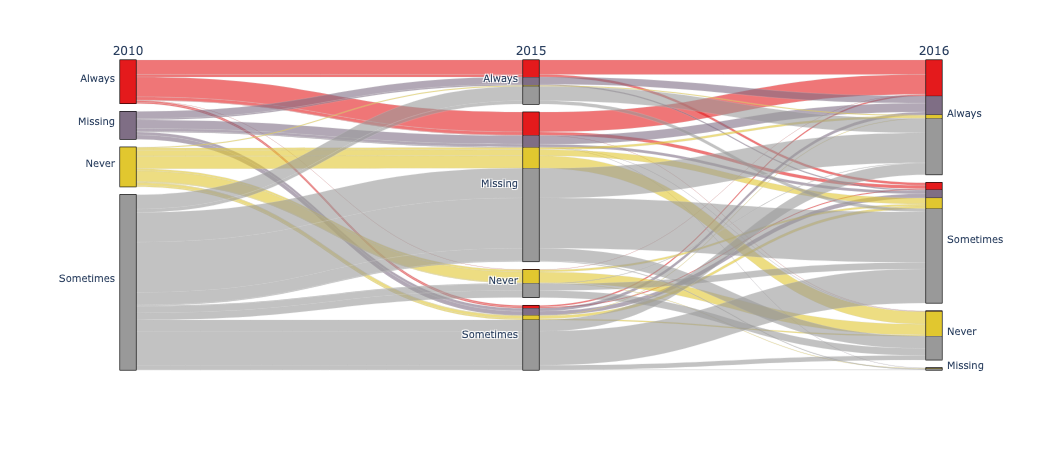

In [222]:
fig = px.parallel_categories(
    vacc_wide_exp, 
    dimensions=vacc_wide_exp.columns,
    color=vacc_wide_exp['2010'].cat.codes,
    color_continuous_scale=plotly_cmap,
    width=800, height=450
)
fig.update_traces(line_shape='hspline')
fig.update_layout(coloraxis_showscale=False)
fig.show()

Notice how many respondents are *Missing* in 2015: more than half of them.

Yet almost all of them answer again in 2016.

Drag the 2015 axis to the end so that 2010 sits next to 2016.

Now we can see that most people who said *Always* in 2010 still said *Always* six years later.

The *Sometimes* group is the least stable.

### Voters switching parties

The `polpan` table follows Polish voters through three parliamentary elections.

It is **wide** already, with a count column `n`.

In [223]:
polpan_data_url = "https://virginia.box.com/shared/static/3lqirf6hzd702y24hoyne6spb5iyn08q.csv"
polpan = pd.read_csv(polpan_data_url)
polpan.info()
polpan.head()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   party2007  51 non-null     str  
 1   party2011  51 non-null     str  
 2   party2015  51 non-null     str  
 3   n          51 non-null     int64
dtypes: int64(1), str(3)
memory usage: 2.4 KB


,party2007,party2011,party2015,n
0,not voted,not voted,not voted,73
1,not voted,not voted,PO,16
2,not voted,not voted,PiS,19
3,not voted,not voted,PSL,3
4,not voted,not voted,Other,9


In [224]:
polpan.columns = [col.replace("party", "") for col in polpan.columns]
group_cols = ['2007', '2011', '2015']
polpan[group_cols] = polpan[group_cols].astype('category')
parties = polpan[group_cols].stack().unique()
parties

['not voted', 'PO', 'PiS', 'PSL', 'Other', 'Left']
Categories (6, str): ['Left', 'Other', 'PO', 'PSL', 'PiS', 'not voted']

In [225]:
polpan_exp = polpan.loc[polpan.index.repeat(polpan['n'])].reset_index(drop=True).drop('n', axis=1)
polpan_exp

,2007,2011,2015
0,not voted,not voted,not voted
1,not voted,not voted,not voted
2,not voted,not voted,not voted
3,not voted,not voted,not voted
4,not voted,not voted,not voted
...,...,...,...
681,Left,Left,Left
682,Other,not voted,PiS
683,Other,not voted,PiS
684,Other,not voted,PiS


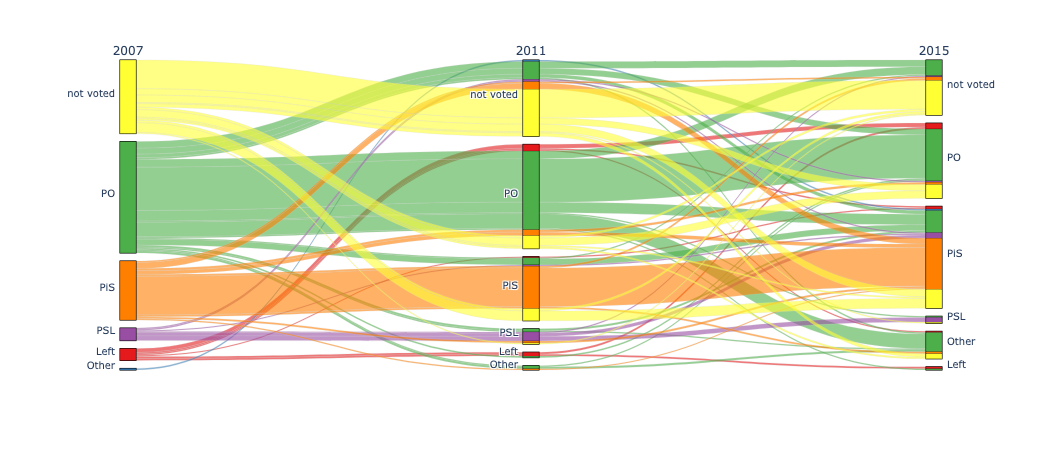

In [226]:
fig = px.parallel_categories(
    polpan_exp, 
    dimensions=polpan_exp.columns, 
    color=polpan_exp['2007'].cat.codes,
    color_continuous_scale=plotly_cmap[:len(polpan_exp['2007'].unique())],
    width=800, height=450
)
fig.update_traces(line_shape='hspline')
fig.update_layout(coloraxis_showscale=False)
fig.show()

How many $2007$ `PO` voters stayed with `PO` in $2015$?

Where did the rest go?

## When alluvial diagrams mislead

### Flows imply that the same individuals are being tracked

The `alluvial` package also includes UNHCR refugee counts for ten countries from 2003 to 2013.

In [227]:
refugees_data_url = "https://virginia.box.com/shared/static/i8unovg5od58s2qlkln25i456d7kpabj.csv"
refugees = pd.read_csv(refugees_data_url)
refugees.head()

,country,year,refugees
0,Afghanistan,2003,2136043
1,Burundi,2003,531637
2,Congo DRC,2003,453465
3,Iraq,2003,368580
4,Myanmar,2003,151384


This table has one row per country per year.

It counts different people each year, though, so nothing connects a refugee in 2003 to a refugee in 2004.

If we pivot `year` onto the columns, there is nothing to put in the cells but a number, and `parallel_categories` has no categories to connect.

In [228]:
refugees_wide = refugees.pivot(index='country', columns='year', values='refugees')
refugees_wide

year,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
country,,,,,,,,,,,
Afghanistan,2136043,2084109,2166149,2107519,1909911,1817913,1905804,3054709,2664436,2586034,2556507
Burundi,531637,485454,438706,396541,375715,281592,94239,84064,101288,73362,72652
Congo DRC,453465,461042,430929,401914,370386,367995,455852,476693,491481,509082,499320
Iraq,368580,311905,262299,1450905,2279245,1873519,1785212,1683575,1428308,746181,401384
Myanmar,151384,161013,164864,202826,191256,184347,206650,215644,214594,215338,222053
Palestine,350568,350617,349673,334142,335219,333990,95177,93299,94121,94820,96044
Somalia,402336,389304,395553,464252,455356,559153,678308,770148,1075148,1136713,1121772
Sudan,606242,730647,693632,686311,523032,397013,348500,379067,491013,558195,636400
Syria,20819,21440,16401,12338,13671,15186,17884,18428,19900,728603,2457255


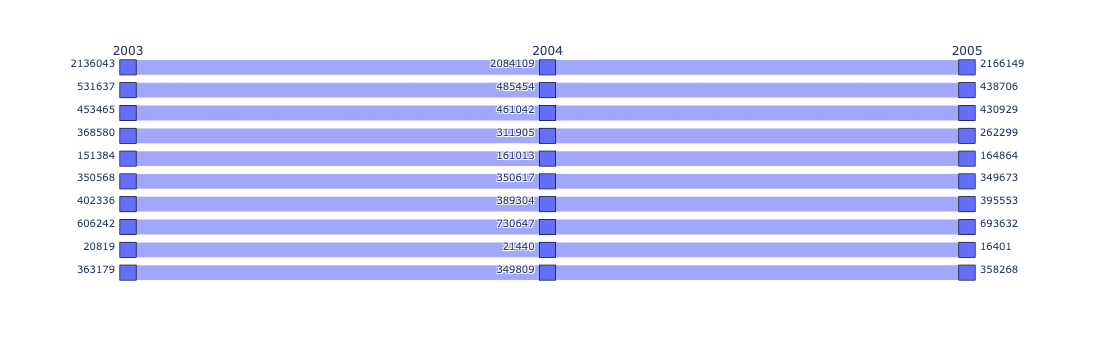

In [229]:
px.parallel_categories(
    refugees_wide.reset_index(),
    dimensions=[2003,2004,2005]
)

The right picture here is a time series, with years on the x axis and one series per country.

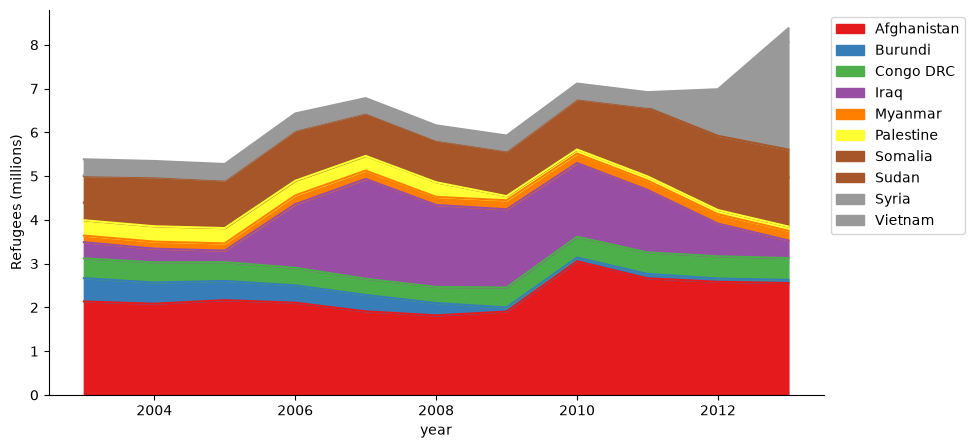

In [230]:
(refugees
    .pivot(index='year', columns='country', values='refugees')
    .div(1e6)
    .plot
    .area(figsize=(10, 5), cmap='Set1', ylabel='Refugees (millions)')
)
plt.legend(bbox_to_anchor=(1, 1))
sns.despine()
plt.show()

```{caution}
An alluvial diagram promises that the flows follow the same observations from axis to axis.

If your data don't link observations across axes, the flows are invented.
```

### Axis order changes the story

The flows connect only *neighboring* axes.

In the Berkeley example, putting `Dept` between `Gender` and `Admit` revealed something that `Gender → Admit` hid.

Try dragging the axes in any of the diagrams above to see how the picture changes.

### Too many categories

Every new category multiplies the number of possible flows.

Bin numeric variables, and lump rare categories into *Other*, before plotting.

### Color can follow only one axis

We colored each diagram by a single variable.

Everything else must be read from the positions of the flows, which is harder.

Choose the coloring variable that carries your main question.

## Summary

- An alluvial diagram shows how observations divide across a sequence of categorical axes.
- `px.parallel_categories` needs a wide table with one row per observation and one column per axis.
- Tidy (long) repeated measures need a `pivot`; counted tables need `index.repeat` with `counts`.
- Color by one variable, fix the order of categories, and keep the number of categories small.
- Only draw flows when the same observations really do pass through every axis.